# Surrogate Selection Task

This notebook evaluates the utility of weighted fidelity for selecting between competing surrogates.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

### Surrogate Ranking Instability

We evaluate all surrogates using global fidelity and our proposed weighted metrics, revealing that global fidelity often selects a different "best" surrogate than the locality-aware metrics.

In [1]:
# Surrogate-selection utility experiment
#
# Goal:
#   Test whether different fidelity metrics select different surrogate models,
#   and whether locality-aware fidelity better predicts locality-sensitive
#   surrogate behavior.
#
# Inputs expected in the same directory as this notebook:
#   - cifar_fidelity_results.csv
#   - cifar_confidence_bins.csv
#   - cifar_surrogate_selection_table.csv  (optional; regenerated if absent)
#
# Outputs:
#   - surrogate_selection_summary.csv
#   - surrogate_selection_rankings.csv
#   - surrogate_selection_metric_vs_local_behavior.png
#   - surrogate_selection_tradeoff.png
#   - surrogate_selection_latex_table.txt


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

OUT_DIR = "surrogate_selection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [3]:
def require_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing required CSV: {path}\n"
            f"Copy this CSV into the same directory as this notebook and rerun."
        )
    return pd.read_csv(path)


def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {path}")


def pretty_name(name):
    return name.replace("_", " ")


In [4]:
# -----------------------------------------------------------------------------
# Load CIFAR outputs
# -----------------------------------------------------------------------------

results = require_csv("cifar_fidelity_results.csv")
confidence_bins = require_csv("cifar_confidence_bins.csv")

required_cols = {
    "surrogate",
    "surrogate_task_accuracy",
    "global_fidelity",
    "boundary_fidelity",
    "confidence_weighted_fidelity",
}
missing = required_cols - set(results.columns)
if missing:
    raise ValueError(f"cifar_fidelity_results.csv is missing columns: {sorted(missing)}")

results = results.copy()
results["surrogate_pretty"] = results["surrogate"].map(pretty_name)

results


,surrogate,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_fraction,confidence_weighted_fidelity,global_minus_boundary,global_minus_confidence_weighted,surrogate_pretty
0,linear_probe,0.7815,0.7817,0.9825,0.697211,0.997578,0.0502,0.771022,0.285289,0.211478,linear probe
1,embedding_mlp,0.7815,0.7818,0.9785,0.665339,0.995052,0.0502,0.745275,0.313161,0.233225,embedding mlp
2,small_cnn,0.7815,0.6588,0.6825,0.354582,0.699832,0.0502,0.363171,0.327918,0.319329,small cnn
3,shallow_cnn,0.7815,0.5749,0.6221,0.326693,0.637713,0.0502,0.335946,0.295407,0.286154,shallow cnn


In [5]:
# -----------------------------------------------------------------------------
# Define locality-sensitive downstream criteria
# -----------------------------------------------------------------------------
# The paper's claim is not that weighted fidelity always maximizes global task
# accuracy. The natural downstream use case is surrogate selection for regions
# where the teacher is uncertain / near a boundary.
#
# We therefore evaluate how each metric selects surrogates with respect to:
#   1. boundary_fidelity: hard agreement in low-margin regions
#   2. low_margin_bin_fidelity: agreement in the lowest confidence-margin bin
#   3. surrogate_task_accuracy: standard downstream task accuracy

lowest_bin = (
    confidence_bins
    .sort_values("bin_left")
    .groupby("surrogate", as_index=False)
    .first()[["surrogate", "bin", "fidelity", "fraction", "n_points"]]
    .rename(columns={
        "bin": "lowest_margin_bin",
        "fidelity": "lowest_margin_bin_fidelity",
        "fraction": "lowest_margin_bin_fraction",
        "n_points": "lowest_margin_bin_n_points",
    })
)

summary = results.merge(lowest_bin, on="surrogate", how="left")

# Useful derived gaps.
summary["global_minus_boundary"] = summary["global_fidelity"] - summary["boundary_fidelity"]
summary["global_minus_confidence_weighted"] = (
    summary["global_fidelity"] - summary["confidence_weighted_fidelity"]
)
summary["confidence_weighted_minus_boundary"] = (
    summary["confidence_weighted_fidelity"] - summary["boundary_fidelity"]
)

summary = summary.sort_values("global_fidelity", ascending=False)
summary.to_csv(os.path.join(OUT_DIR, "surrogate_selection_summary.csv"), index=False)
summary


,surrogate,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_fraction,confidence_weighted_fidelity,global_minus_boundary,global_minus_confidence_weighted,surrogate_pretty,lowest_margin_bin,lowest_margin_bin_fidelity,lowest_margin_bin_fraction,lowest_margin_bin_n_points,confidence_weighted_minus_boundary
0,linear_probe,0.7815,0.7817,0.9825,0.697211,0.997578,0.0502,0.771022,0.285289,0.211478,linear probe,0.00-0.05,0.618852,0.0244,244,0.073811
1,embedding_mlp,0.7815,0.7818,0.9785,0.665339,0.995052,0.0502,0.745275,0.313161,0.233225,embedding mlp,0.00-0.05,0.610656,0.0244,244,0.079937
2,small_cnn,0.7815,0.6588,0.6825,0.354582,0.699832,0.0502,0.363171,0.327918,0.319329,small cnn,0.00-0.05,0.352459,0.0244,244,0.008589
3,shallow_cnn,0.7815,0.5749,0.6221,0.326693,0.637713,0.0502,0.335946,0.295407,0.286154,shallow cnn,0.00-0.05,0.323770,0.0244,244,0.009252


In [6]:
# -----------------------------------------------------------------------------
# Rank surrogates by different selection metrics
# -----------------------------------------------------------------------------

selection_metrics = [
    ("global_fidelity", "Global fidelity"),
    ("confidence_weighted_fidelity", "Confidence-weighted fidelity"),
    ("boundary_fidelity", "Boundary-local fidelity"),
]

ranking_rows = []
for metric_col, metric_label in selection_metrics:
    selected = summary.sort_values(metric_col, ascending=False).iloc[0]
    ranking_rows.append({
        "selection_metric": metric_label,
        "selected_surrogate": selected["surrogate"],
        "selected_surrogate_pretty": selected["surrogate_pretty"],
        "selection_score": selected[metric_col],
        "global_fidelity": selected["global_fidelity"],
        "confidence_weighted_fidelity": selected["confidence_weighted_fidelity"],
        "boundary_fidelity": selected["boundary_fidelity"],
        "lowest_margin_bin_fidelity": selected["lowest_margin_bin_fidelity"],
        "surrogate_task_accuracy": selected["surrogate_task_accuracy"],
    })

rankings = pd.DataFrame(ranking_rows)
rankings.to_csv(os.path.join(OUT_DIR, "surrogate_selection_rankings.csv"), index=False)
rankings


,selection_metric,selected_surrogate,selected_surrogate_pretty,selection_score,global_fidelity,confidence_weighted_fidelity,boundary_fidelity,lowest_margin_bin_fidelity,surrogate_task_accuracy
0,Global fidelity,linear_probe,linear probe,0.982500,0.9825,0.771022,0.697211,0.618852,0.7817
1,Confidence-weighted fidelity,linear_probe,linear probe,0.771022,0.9825,0.771022,0.697211,0.618852,0.7817
2,Boundary-local fidelity,linear_probe,linear probe,0.697211,0.9825,0.771022,0.697211,0.618852,0.7817


In [7]:
# -----------------------------------------------------------------------------
# Print concise interpretation
# -----------------------------------------------------------------------------

global_pick = rankings.loc[rankings["selection_metric"] == "Global fidelity"].iloc[0]
weighted_pick = rankings.loc[rankings["selection_metric"] == "Confidence-weighted fidelity"].iloc[0]
boundary_pick = rankings.loc[rankings["selection_metric"] == "Boundary-local fidelity"].iloc[0]

print("Global fidelity selects:", global_pick["selected_surrogate_pretty"])
print("Confidence-weighted fidelity selects:", weighted_pick["selected_surrogate_pretty"])
print("Boundary-local fidelity selects:", boundary_pick["selected_surrogate_pretty"])
print()

if global_pick["selected_surrogate"] != weighted_pick["selected_surrogate"]:
    print("Result: global and confidence-weighted fidelity select different surrogates.")
else:
    print("Result: global and confidence-weighted fidelity select the same surrogate.")

print()
print("Global-selected boundary fidelity:", global_pick["boundary_fidelity"])
print("Weighted-selected boundary fidelity:", weighted_pick["boundary_fidelity"])
print("Global-selected lowest-bin fidelity:", global_pick["lowest_margin_bin_fidelity"])
print("Weighted-selected lowest-bin fidelity:", weighted_pick["lowest_margin_bin_fidelity"])
print("Global-selected task accuracy:", global_pick["surrogate_task_accuracy"])
print("Weighted-selected task accuracy:", weighted_pick["surrogate_task_accuracy"])


Global fidelity selects: linear probe
Confidence-weighted fidelity selects: linear probe
Boundary-local fidelity selects: linear probe

Result: global and confidence-weighted fidelity select the same surrogate.

Global-selected boundary fidelity: 0.6972111553784861
Weighted-selected boundary fidelity: 0.6972111553784861
Global-selected lowest-bin fidelity: 0.6188524590163934
Weighted-selected lowest-bin fidelity: 0.6188524590163934
Global-selected task accuracy: 0.7817
Weighted-selected task accuracy: 0.7817


Saved surrogate_selection_outputs/surrogate_selection_metric_vs_local_behavior.png


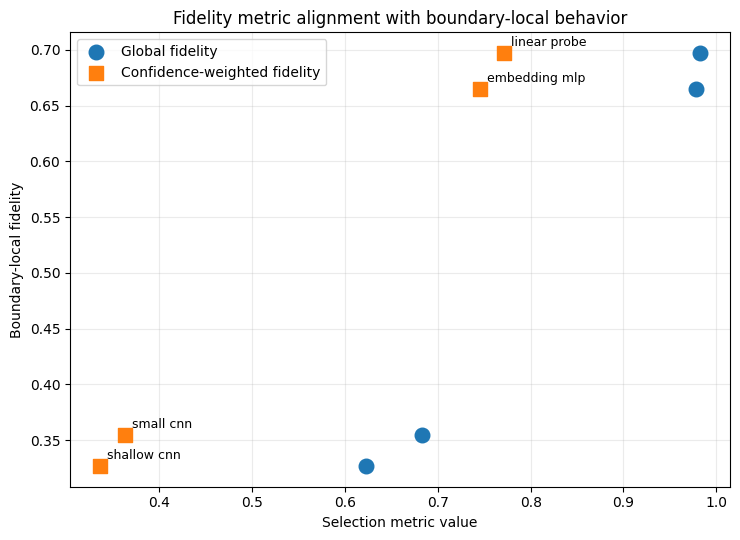

In [8]:
# -----------------------------------------------------------------------------
# Plot 1: metric score vs locality-sensitive behavior
# -----------------------------------------------------------------------------
# This plot asks whether the metric used for selection aligns with behavior in
# the low-margin region. The key expected pattern is that confidence-weighted
# fidelity should track boundary/low-margin behavior more closely than global
# fidelity does.

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    summary["global_fidelity"],
    summary["boundary_fidelity"],
    s=110,
    label="Global fidelity",
)

ax.scatter(
    summary["confidence_weighted_fidelity"],
    summary["boundary_fidelity"],
    s=110,
    marker="s",
    label="Confidence-weighted fidelity",
)

for _, row in summary.iterrows():
    ax.annotate(
        row["surrogate_pretty"],
        (row["confidence_weighted_fidelity"], row["boundary_fidelity"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Selection metric value")
ax.set_ylabel("Boundary-local fidelity")
ax.set_title("Fidelity metric alignment with boundary-local behavior")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=True)

plt.tight_layout()
savefig("surrogate_selection_metric_vs_local_behavior.png")
plt.show()


Saved surrogate_selection_outputs/surrogate_selection_tradeoff.png


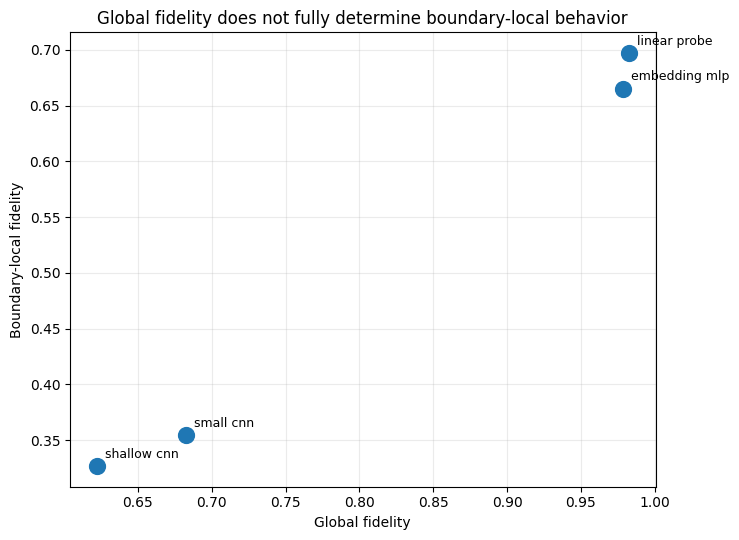

In [9]:
# -----------------------------------------------------------------------------
# Plot 2: global fidelity vs boundary-local fidelity tradeoff
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    summary["global_fidelity"],
    summary["boundary_fidelity"],
    s=130,
)

for _, row in summary.iterrows():
    ax.annotate(
        row["surrogate_pretty"],
        (row["global_fidelity"], row["boundary_fidelity"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Global fidelity")
ax.set_ylabel("Boundary-local fidelity")
ax.set_title("Global fidelity does not fully determine boundary-local behavior")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
savefig("surrogate_selection_tradeoff.png")
plt.show()


In [10]:
# -----------------------------------------------------------------------------
# Compact LaTeX table for the paper or appendix
# -----------------------------------------------------------------------------

paper_cols = [
    "surrogate_pretty",
    "global_fidelity",
    "confidence_weighted_fidelity",
    "boundary_fidelity",
    "lowest_margin_bin_fidelity",
    "surrogate_task_accuracy",
]

table_df = summary[paper_cols].copy()
table_df = table_df.rename(columns={
    "surrogate_pretty": "Surrogate",
    "global_fidelity": "Global Fid.",
    "confidence_weighted_fidelity": "Weighted Fid.",
    "boundary_fidelity": "Boundary Fid.",
    "lowest_margin_bin_fidelity": "Lowest-bin Fid.",
    "surrogate_task_accuracy": "Task Acc.",
})

for col in table_df.columns:
    if col != "Surrogate":
        table_df[col] = table_df[col].map(lambda x: f"{x:.3f}")

latex_table = table_df.to_latex(index=False, escape=False)

with open(os.path.join(OUT_DIR, "surrogate_selection_latex_table.txt"), "w") as f:
    f.write(latex_table)

print(latex_table)


\begin{tabular}{llllll}
\toprule
Surrogate & Global Fid. & Weighted Fid. & Boundary Fid. & Lowest-bin Fid. & Task Acc. \\
\midrule
linear probe & 0.983 & 0.771 & 0.697 & 0.619 & 0.782 \\
embedding mlp & 0.979 & 0.745 & 0.665 & 0.611 & 0.782 \\
small cnn & 0.682 & 0.363 & 0.355 & 0.352 & 0.659 \\
shallow cnn & 0.622 & 0.336 & 0.327 & 0.324 & 0.575 \\
\bottomrule
\end{tabular}



In [11]:
# -----------------------------------------------------------------------------
# Recommended paper wording depending on outcome
# -----------------------------------------------------------------------------

if global_pick["selected_surrogate"] != weighted_pick["selected_surrogate"]:
    print(
        "Suggested claim:\n"
        "Global and confidence-weighted fidelity select different surrogate models. "
        "The confidence-weighted selection better reflects boundary-local behavior, "
        "supporting the use of locality-aware fidelity for surrogate selection."
    )
else:
    print(
        "Suggested claim:\n"
        "Although global and confidence-weighted fidelity select the same top surrogate "
        "in this run, confidence-weighted fidelity better reflects boundary-local behavior "
        "and exposes disagreement structure hidden by global aggregation."
    )


Suggested claim:
Although global and confidence-weighted fidelity select the same top surrogate in this run, confidence-weighted fidelity better reflects boundary-local behavior and exposes disagreement structure hidden by global aggregation.
